<a href="https://colab.research.google.com/github/Wajdals/Early-ASD-Autism-Spectrum-Disorder-Screening/blob/main/autism_screening%20Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
import pandas as pd

In [73]:
df = pd.read_csv ("Autism Spectrum Disorder Screening Data for Toddlers in Saudi Arabia Data Set.csv")

In [74]:
df.head()

,A10,A9,A8,A7,A6,A5,A4,A3,A2,A1,Region,Family member with ASD history,Who is completing the test,Age,Gender,Screening Score,Class
0,0,0,1,1,1,0,0,0,0,0,Makkah Province,No,Family member,32,Female,3,0
1,0,0,1,0,0,1,0,1,0,0,Makkah Province,No,Family member,30,Female,3,0
2,0,0,0,1,0,0,0,0,0,0,Makkah Province,No,Family member,36,Male,1,0
3,0,0,0,0,0,0,0,0,0,0,Makkah Province,Yes,Family member,36,Female,0,0
4,0,0,0,0,0,0,0,0,0,0,Eastern Province,No,Family member,36,Female,0,0


In [75]:
df.isnull().sum()

,0
A10,0
A9,0
A8,0
A7,0
A6,0
A5,0
A4,0
A3,0
A2,0
A1,0


In [76]:
import duckdb

In [77]:
Data = duckdb.sql("""
    select
    A1 AS "Looks When Name Called",
    A2 AS "Eye Contact",
    A3 AS "Points To Request",
    A4 AS "Points To Share Interest",
    A5 AS "Pretend Play",
    A6 AS "Follows Gaze",
    A7 AS "Comforts Others",
    A8 AS "First Word",
    A9 AS "Uses Gestures",
    A10 AS "Staring",
    Region,
    "Family member with ASD history",
    "Who is completing the test",
    Age,
    Gender,
    "Screening Score",

  case
    when Class = 0 then 'Negative screening'
    when Class = 1 then 'Positive screening'
  end as "ASD traits"
FROM df ;
""").df()

Data

,Looks When Name Called,Eye Contact,Points To Request,Points To Share Interest,Pretend Play,Follows Gaze,Comforts Others,First Word,Uses Gestures,Staring,Region,Family member with ASD history,Who is completing the test,Age,Gender,Screening Score,ASD traits
0,0,0,0,0,0,1,1,1,0,0,Makkah Province,No,Family member,32,Female,3,Negative screening
1,0,0,1,0,1,0,0,1,0,0,Makkah Province,No,Family member,30,Female,3,Negative screening
2,0,0,0,0,0,0,1,0,0,0,Makkah Province,No,Family member,36,Male,1,Negative screening
3,0,0,0,0,0,0,0,0,0,0,Makkah Province,Yes,Family member,36,Female,0,Negative screening
4,0,0,0,0,0,0,0,0,0,0,Eastern Province,No,Family member,36,Female,0,Negative screening
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0,1,0,1,1,1,0,1,1,0,Madinah Province,No,Family member,35,Male,6,Positive screening
502,1,1,1,1,0,0,1,1,1,0,Qassim Province,No,Other,32,Female,7,Positive screening
503,0,1,0,0,1,1,1,1,1,1,Najran Province,Yes,Family member,29,Female,7,Positive screening
504,0,0,0,0,1,1,1,1,1,0,Madinah Province,No,Family member,15,Female,5,Positive screening


In [78]:
# Less than or equal 3 no ASD traits; > 3 ASD traits
Data_valid_score = duckdb.sql ("""
    SELECT
    "ASD traits",
    "Screening Score"
    FROM Data
    WHERE
    ("ASD traits" = 'Negative screening' AND "Screening Score" > 3 )
    OR
    ("ASD traits" = 'Positive screening' AND "Screening Score" <= 3 )

""")

Data_valid_score

┌────────────┬─────────────────┐
│ ASD traits │ Screening Score │
│  varchar   │      int64      │
├────────────┴─────────────────┤
│            0 rows            │
└──────────────────────────────┘

In [79]:
# Toddlers (months) aged 12-36 months
age_valid = duckdb.sql("""

    select Age
    from Data
    where
    age > 37 or age < 11

""")

age_valid

┌────────┐
│  Age   │
│ int64  │
├────────┤
│ 0 rows │
└────────┘

In [80]:
# family and screening needs
family_ASD_traits = duckdb.sql("""
    select
    "ASD traits",
    "Family member with ASD history",
    count(*) as "Total Count"
    from Data
    group by "ASD traits", "Family member with ASD history"

""").df()

family_ASD_traits

,ASD traits,Family member with ASD history,Total Count
0,Negative screening,No,147
1,Positive screening,Yes,104
2,Negative screening,Yes,18
3,Positive screening,No,237


In [81]:
df["Family member with ASD history"] = df["Family member with ASD history"].replace({
    "Yes": 1,
    "No": 0
})
df["Gender"] = df["Gender"].replace({
    "Female" : 1,
    "Male" : 0

})

corr = df.corr(numeric_only=True)

/tmp/ipykernel_2299/2023442334.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Family member with ASD history"] = df["Family member with ASD history"].replace({
/tmp/ipykernel_2299/2023442334.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Gender"] = df["Gender"].replace({


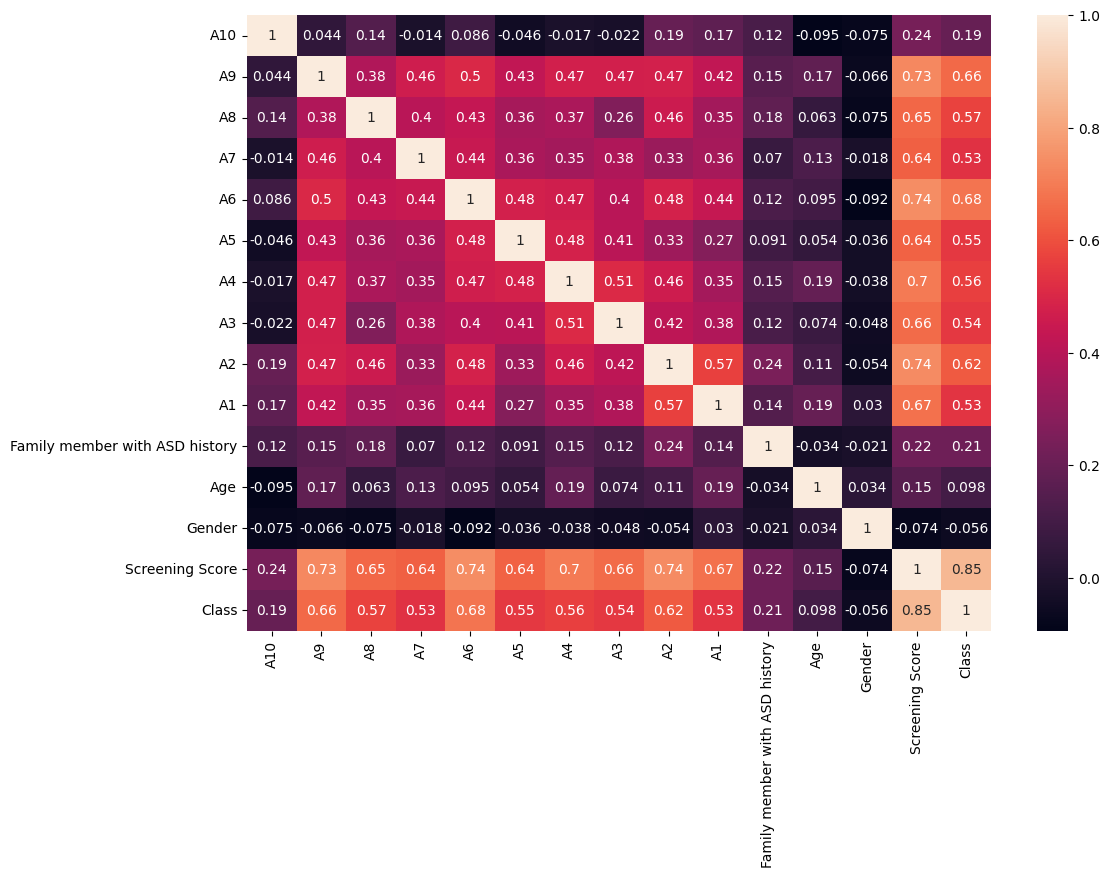

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(corr, annot=True)

plt.show()

In [83]:
Data.to_csv("ASD_Screening_Cleaned.csv", index=False)